# Getting started with MemsArrayWS objects

The `MemsArrayWS` class allows getting signals from a remote antenna running a local *Megamicros Broadcast Server (MBS)* server. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros.core.ws import MemsArrayWS

log.setLevel( "INFO" )

# Set server access credentials
HOST = 'buzenval20.fr'
PORT = 9002

## Connecting to the remote server

Providing a *MBS* server is running at ``HOST:PORT``, one can try to connect by creating a ``MemsArrayWS`` object.

In [ ]:
# Define the antenna
try:
    antenna = MemsArrayWS( HOST, port=PORT, truc="truc" )
except Exception as e:
    print( f"Failed: {e}" )


2023-10-05 17:39:41,024 [INFO]:  .Install MemsArrayWS settings
2023-10-05 17:39:41,025 [INFO]:  .Created a new antenna
2023-10-05 17:39:41,027 [INFO]:  .Install MemsArrayWS settings
2023-10-05 17:39:41,027 [INFO]:  .Async event loop already running. Adding coroutine to the event loop...


2023-10-05 17:39:41,030 [INFO]:  .Try connecting to ws://buzenval20.fr:9002...
2023-10-05 17:39:41,066 [INFO]:  .Received positive answer from server
2023-10-05 17:39:41,067 [INFO]:  .Getting settings values from remote receiver...
2023-10-05 17:39:41,622 [INFO]:  .Received settings from server [ok]
2023-10-05 17:39:41,624 [INFO]:  .Set 8 available MEMs numbered from 0 to 7
2023-10-05 17:39:41,626 [INFO]:  .No analogic channels available
2023-10-05 17:39:41,632 [INFO]:  .Starting MegamicrosWS device [ready]


## Running

### Getting signals from some MEMs

In [4]:
# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [1, 2],
    duration=2,
    buffer_length=512,
    signal_q_size = 0,
)

# Init a np.ndarray
signals = np.ndarray( (0, antenna.channels_number ) )

# Get signals
for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna.wait()
print( f"exit from loop. Signal shape is: {np.shape( signals )}" )

2023-10-05 17:41:51,408 [INFO]:  .Starting run execution
2023-10-05 17:41:51,410 [INFO]:  .Install MemsArray.run() settings
2023-10-05 17:41:51,411 [INFO]:  .2 MEMs were activated among 0 to 7 available MEMs
2023-10-05 17:41:51,412 [INFO]:  .Install MemsArrayWS settings
2023-10-05 17:41:51,413 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-05 17:41:51,414 [INFO]:  .Perform a 2s run loop
2023-10-05 17:41:51,415 [INFO]:  .H5 recording off
2023-10-05 17:41:51,415 [INFO]:  .Background execution mode off
2023-10-05 17:41:51,417 [INFO]:  .Run thread execution started
2023-10-05 17:41:51,417 [INFO]:  .Starting iterations: will produce data as numpy array of int32 (256 x 2 size)
2023-10-05 17:41:51,418 [INFO]:  .Connecting to remote host buzenval20.fr:9002...
2023-10-05 17:41:51,430 [INFO]:  .Connected
2023-10-05 17:41:51,431 [INFO]:  .Send running job command
2023-10-05 17:41:51,436 [INFO]:  .Run command accepted by server
2023-10-05 17:41:55,053 [INFO]:  .Received end of service 

exit from loop. Signal shape is: (98304, 2)


## Plotting signals

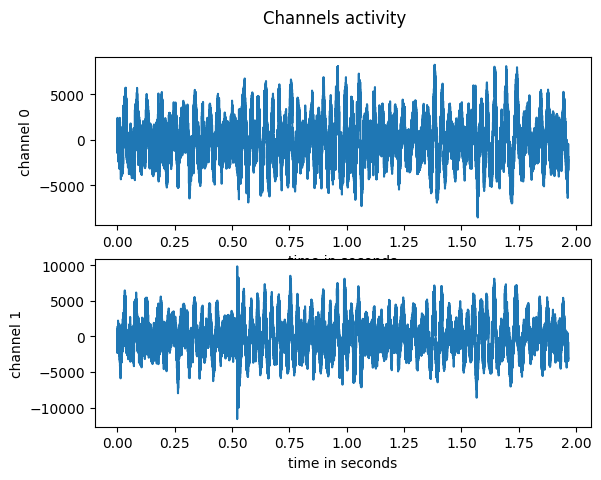

In [5]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

## Saving signals as wav file

In [7]:
import wave

WAV_FILENAME = 'toto.wav'

# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [1, 2],
    duration=5,
    buffer_length=512,
    signal_q_size = 0,
)

with  wave.open( WAV_FILENAME, mode='wb' ) as wavfile:
    wavfile.setnchannels(2)
    wavfile.setsampwidth(2)
    wavfile.setframerate( antenna.sampling_frequency )

    # Get signals
    for data in antenna:
        signal = data >> 4
        wavfile.writeframesraw( np.int16( np.reshape( signal, np.size( signal ), order='F' ) ) )

# waiting for the end of the running thread is mandatory
antenna.wait()

2023-10-05 17:59:32,653 [INFO]:  .Starting run execution
2023-10-05 17:59:32,655 [INFO]:  .Install MemsArray.run() settings
2023-10-05 17:59:32,656 [INFO]:  .2 MEMs were activated among 0 to 7 available MEMs
2023-10-05 17:59:32,658 [INFO]:  .Install MemsArrayWS settings
2023-10-05 17:59:32,658 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-05 17:59:32,659 [INFO]:  .Perform a 5s run loop
2023-10-05 17:59:32,660 [INFO]:  .H5 recording off
2023-10-05 17:59:32,660 [INFO]:  .Background execution mode off
2023-10-05 17:59:32,661 [INFO]:  .Run thread execution started
2023-10-05 17:59:32,662 [INFO]:  .Starting iterations: will produce data as numpy array of int32 (256 x 2 size)
2023-10-05 17:59:32,663 [INFO]:  .Connecting to remote host buzenval20.fr:9002...
2023-10-05 17:59:32,674 [INFO]:  .Connected
2023-10-05 17:59:32,675 [INFO]:  .Send running job command
2023-10-05 17:59:32,681 [INFO]:  .Run command accepted by server
2023-10-05 17:59:39,282 [INFO]:  .Received end of service 

## Hearing signal with *pyaudio* library

In [11]:
import pyaudio

FRAME_LENGTH = 256

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[1, 2],
    duration=10,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ).T * antenna.sensibility )

    # write into audio stream
    stream.write( data, num_frames=FRAME_LENGTH )
    transfers_counter += 1

# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()


2023-10-08 22:15:53,020 [INFO]:  .Starting run execution
2023-10-08 22:15:53,022 [INFO]:  .Install MemsArray.run() settings
2023-10-08 22:15:53,023 [INFO]:  .2 MEMs were activated among 0 to 7 available MEMs
2023-10-08 22:15:53,025 [INFO]:  .Install MemsArrayWS settings
2023-10-08 22:15:53,025 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-08 22:15:53,026 [INFO]:  .Perform a 10s run loop
2023-10-08 22:15:53,027 [INFO]:  .H5 recording off
2023-10-08 22:15:53,028 [INFO]:  .Background execution mode off
2023-10-08 22:15:53,029 [INFO]:  .Run thread execution started
2023-10-08 22:15:53,030 [INFO]:  .Starting iterations: will produce data as numpy array of int32 (256 x 2 size)
2023-10-08 22:15:53,031 [INFO]:  .Connecting to remote host buzenval20.fr:9002...
2023-10-08 22:15:53,053 [INFO]:  .Connected
2023-10-08 22:15:53,057 [INFO]:  .Send running job command
2023-10-08 22:15:53,063 [INFO]:  .Run command accepted by server
2023-10-08 22:16:04,714 [INFO]:  .Received end of service

## Saving signals

You can save signal in H5 file format. In this example sigansl are saved on the MBS remote server.
The antenna receive no more signals. 

In [ ]:
antenna.run(
    mems = [3, 4],
    duration=2,
    buffer_length=512,
    h5_recording=True,                          # H5 recording ON
    h5_pass_through=True,                       # perform F5 recording on server
    h5_rootdir='./',                            # directory where to save file
    h5_compressing=False,                       # Use compression or not
    background_mode=True,
    signal_q_size = 0,
)

antenna.wait()

## Getting signals yourself

In this example, signals are received using the antenna internal queue.

In [ ]:
import queue

antenna.run(
    mems = [1, 2],
    duration=2,
    buffer_length=512,
    signal_q_size = 0,
)

i = 0
while True:
    try:
        data = antenna.signal_q.get( timeout=5 )
        print( f"[{i}]" )
        i += 1
        # do what you want with data...

    except queue.Empty:
        print( f"exit from loop at i={i}" )
        break

antenna.wait()